In [1]:
"""Generate paper/figures/matr2_rul_density.png -- two-panel, shared RUL x-axis:
  top:    current result -> how bad it is (per-cell test error vs. true RUL)
  bottom: why -> train_base's RUL density, showing the high-RUL tail is thin
          exactly where the worst errors are.

Sources:
  - ipynb/exp_v3/matr1_feature_cache/matr2_v1v2inter_ensemble_seed0.pkl
    (per-cell test predictions/errors for the designated result, RMSE 210.7)
  - ipynb/exp_v3/matr1_feature_cache/feature_cache_matr2.pkl (train_base_label)
"""
import os
import pickle

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!pip install seaborn

In [5]:
REPO = r"C:\Users\TommyPhan_Exp\Desktop\course\Kaggle\batteryml\BatteryML"
PRED_PKL = os.path.join(REPO, "ipynb", "exp_v3", "matr1_feature_cache", "matr2_v1v2inter_ensemble_seed0.pkl")
CACHE_PKL = os.path.join(REPO, "ipynb", "exp_v3", "matr1_feature_cache", "feature_cache_matr2.pkl")

BLUE = "#4C72B0"
RED = "#C44E52"


def as_np(x):
    return x.numpy() if hasattr(x, "numpy") else np.asarray(x)


with open(PRED_PKL, "rb") as f:
    pred = pickle.load(f)
test_true = as_np(pred["test_true"]).flatten()
test_pred = as_np(pred["ens_test"]).flatten()
err = test_pred - test_true

with open(CACHE_PKL, "rb") as f:
    d = pickle.load(f)
train_base = as_np(d["train_base_label"]).flatten()

META_PKL = REPO + r"\ipynb\exp_v3\data_split\feature_raw_cache.pkl"

with open(META_PKL, "rb") as f:
    _, meta = pickle.load(f)   # meta is a pandas DataFrame indexed by cell_id

# meta.official_role tags every cell with its role in BatteryML's own split:
# "MATR1_train", "MATR1_test", "MATR34" (b3/b4), "HUST", etc.
m1tr_rul = meta.loc[meta.official_role == "MATR1_train", "rul"].to_numpy(dtype=float)

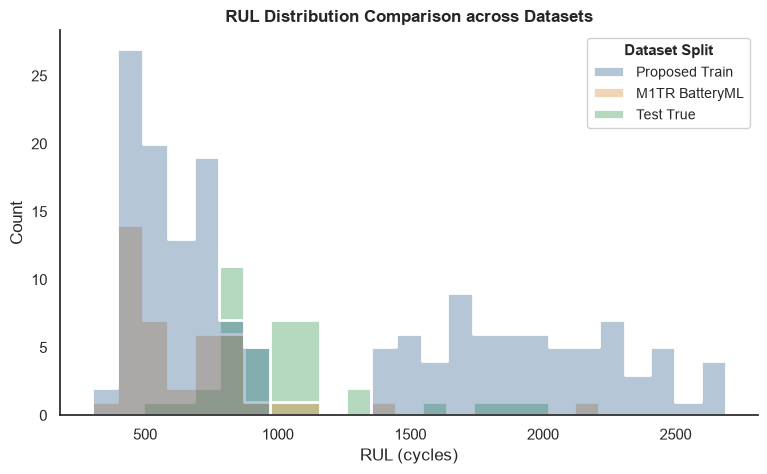

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Build DataFrame and rename dataset names directly for clean legend labels
df_combined = pd.concat([
    pd.DataFrame({"RUL": train_base, "Dataset": "Proposed Train"}),
    pd.DataFrame({"RUL": m1tr_rul, "Dataset": "M1TR BatteryML"}),
    pd.DataFrame({"RUL": test_true, "Dataset": "Test True"})
], ignore_index=True)

# 2. Plot combined on a single axes with matching palette keys
sns.set_theme(style="white")
palette = {
    "Proposed Train": "#2b5c8f", 
    "M1TR BatteryML": "#d9822b", 
    "Test True": "#2b9348"
}
plt.figure(figsize=(9, 5))
ax = sns.histplot(
    data=df_combined,
    x="RUL",
    hue="Dataset",
    palette=palette,
    bins=25,
    element="step",      # Outlines the distributions clearly
    stat="count",
    common_norm=False,
    alpha=0.35,          # Transparency so overlaps are visible
    edgecolor="white",
    linewidth=2
)

plt.title("RUL Distribution Comparison across Datasets", fontsize=12, fontweight="bold")
plt.xlabel("RUL (cycles)")
plt.ylabel("Count")
sns.despine()

# 3. Safely customize the existing legend box styling
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Dataset Split")
    legend.get_title().set_fontsize("11")
    legend.get_title().set_fontweight("bold")
    for text in legend.get_texts():
        text.set_fontsize("10")
    # Frame styling
    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("#cccccc")
    frame.set_alpha(0.9)

# Display inline in Jupyter
plt.show()